# A2 – Initial-Conditions Ingestion Benchmark

Benchmarks end-to-end ingestion time for all IC backends available in `aifs_modal`:

| # | Backend | Runs | Source | Credentials |
|---|---------|------|--------|-------------|
| 1 | **IFS from open-data** | local | ECMWF open-data S3 (AWS) | none |
| 2 | **ERA5 from CDS** | local | Copernicus CDS API | `~/.cdsapirc` or `CDSAPI_*` env vars |
| 3 | **IFS from Brightband** | Modal (`us-east`) | Brightband ECMWF IFS on ArrayLake (zarr) | `ARRAYLAKE_API_TOKEN` |
| 4 | **ERA5 from ARCO** | Modal (`us-central1`) | Google Cloud Storage zarr (anonymous) | none |

Local backends (1–2) write to a temporary directory; Modal backends (3–4) write into the shared IC Volume. The comparison covers the full round trip: `fetch → regrid → zarr write`.

Each benchmark ingests **two timesteps** (t-6h and t) — the minimum needed for a forecast.

> **Prerequisites:** `~/.cdsapirc` or `CDSAPI_URL`/`CDSAPI_KEY` env vars for ERA5 from CDS; `ARRAYLAKE_API_TOKEN` for Brightband; a Modal workspace for ARCO.

In [ ]:
import datetime as dt
import tempfile
import time

import matplotlib.pyplot as plt
import pandas as pd

import aifs_modal
from aifs_modal import _ingest_ekd

## Configuration

Two consecutive 6-hourly analysis dates (t-6h and t).  Each backend fetches
~94 global variables, regrids from 0.25° lat/lon to N320, and writes two zarr
groups into the target bucket.

Set `STORAGE_BUCKET` to a bucket you can write to, and the `PREFIX_*`
values to throwaway key prefixes — this notebook will write and commit real
data there.

In [ ]:
# Brightband source repo (ECMWF IFS initial conditions on ArrayLake)
SOURCE_AL_REPO = "martibosch/ecmwf-ifs-hres-ics-open"

_today_00z = dt.datetime.now(dt.UTC).replace(hour=0, minute=0, second=0, microsecond=0)

# IFS sources (ifs-arraylake): 2 days ago — safely within all rolling windows
_ifs_end = _today_00z - dt.timedelta(days=2)
IFS_DATE_START = (_ifs_end - dt.timedelta(hours=6)).isoformat()
IFS_DATE_END = _ifs_end.isoformat()

# ERA5 sources (era5-arco): 7 days ago — past the ~5-day publication lag
_era5_end = _today_00z - dt.timedelta(days=7)
ERA5_DATE_START = (_era5_end - dt.timedelta(hours=6)).isoformat()
ERA5_DATE_END = _era5_end.isoformat()

print(f"IFS  dates : {IFS_DATE_START} → {IFS_DATE_END}")
print(f"ERA5 dates : {ERA5_DATE_START} → {ERA5_DATE_END}")

IFS  dates : 2026-05-11T18:00:00+00:00 → 2026-05-12T00:00:00+00:00
ERA5 dates : 2026-05-06T18:00:00+00:00 → 2026-05-07T00:00:00+00:00


## 1. IFS initial conditions from CDS (local)

Fetches ECMWF open-data GRIB from AWS, regrids to N320, and writes the
zarr group to the target bucket.  No credentials needed.

In [ ]:
with tempfile.TemporaryDirectory() as ic_dir:
    t0 = time.perf_counter()
    _ingest_ekd.ingest(IFS_DATE_START, IFS_DATE_END, ic_dir, "ifs-ekd")
    ifs_ekd_elapsed = time.perf_counter() - t0

print(f"IFS from open-data (local): ingested in {ifs_ekd_elapsed:.1f} s")

[1/2] ingesting ifs-ekd 2026-05-11T18:00:00+00:00


20260511180000-0h-scda-fc.grib2:   0%|          | 0.00/854k [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.


20260511180000-0h-scda-fc.grib2:   0%|          | 0.00/849k [00:00<?, ?B/s]

20260511180000-0h-scda-fc.grib2:   0%|          | 0.00/672k [00:00<?, ?B/s]

...

<multiple>:   0%|          | 0.00/8.83M [00:00<?, ?B/s]

<multiple>:   0%|          | 0.00/9.13M [00:00<?, ?B/s]

<multiple>:   0%|          | 0.00/15.3M [00:00<?, ?B/s]

<multiple>:   0%|          | 0.00/8.89M [00:00<?, ?B/s]

Wrote ifs-ekd initial conditions from 2026-05-11T18:00:00+00:00 to 2026-05-12T00:00:00+00:00 (2/2 new dates)
IFS from open-data (local): ingested in 233.8 s


## 2. ERA5 from CDS (local)

Submits CDS API requests (surface, soil, pressure-level), waits for the
jobs to complete on the CDS side, downloads GRIB files, regrids to N320,
and writes to the bucket.  Latency is dominated by the CDS queue and
download time over the public internet.

In [ ]:
with tempfile.TemporaryDirectory() as ic_dir:
    t0 = time.perf_counter()
    _ingest_ekd.ingest(ERA5_DATE_START, ERA5_DATE_END, ic_dir, "era5-cds")
    era5_cds_elapsed = time.perf_counter() - t0

print(f"ERA5 from CDS (local): ingested in {era5_cds_elapsed:.1f} s")

[1/2] ingesting era5-cds 2026-05-06T18:00:00+00:00


2026-05-14 08:33:23,982 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-05-14 08:33:23,983 INFO Request ID is 58d91866-ae26-4059-98fc-d688dc1dcd1a
2026-05-14 08:33:24,038 INFO status has been updated to accepted
2026-05-14 08:33:37,726 INFO status has been updated to running
2026-05-14 08:33:57,466 INFO status has been updated to successful


f56514ebb6cfb29583fa61edeca4df04.grib:   0%|          | 0.00/27.7M [00:00<?, ?B/s]

2026-05-14 08:34:04,020 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-05-14 08:34:04,020 INFO Request ID is a13447c0-6a10-41e2-a7b3-8635bd149b38
2026-05-14 08:34:04,067 INFO status has been updated to accepted
2026-05-14 08:34:19,115 INFO status has been updated to running
2026-05-14 08:34:26,761 INFO status has been updated to successful


fb9de0e715158153daad71a99c43dddf.grib:   0%|          | 0.00/7.92M [00:00<?, ?B/s]

...

2026-05-14 08:35:57,585 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-05-14 08:35:57,586 INFO Request ID is f7685d25-c809-4438-90d8-8fd0eeddcab2
2026-05-14 08:36:00,500 INFO status has been updated to accepted
2026-05-14 08:36:24,010 INFO status has been updated to successful


34debd0d4b80987eb266b3f18d2bf90f.grib:   0%|          | 0.00/7.92M [00:00<?, ?B/s]

2026-05-14 08:36:26,548 INFO Request ID is 18125175-81ed-4fdb-a4f3-28bba98737c5
2026-05-14 08:36:26,595 INFO status has been updated to accepted
2026-05-14 08:36:40,735 INFO status has been updated to running
2026-05-14 08:36:50,730 INFO status has been updated to successful


16ac95187ed69b3b09ceaf0c21ed847d.grib:   0%|          | 0.00/154M [00:00<?, ?B/s]

Wrote era5-cds initial conditions from 2026-05-06T18:00:00+00:00 to 2026-05-07T00:00:00+00:00 (2/2 new dates)
ERA5 from CDS (local): ingested in 252.3 s


## 3. IFS initial conditions from Brightband (local)

Reads zarr data directly from the Brightband ECMWF IFS dataset on the
Earthmover ArrayLake marketplace, maps variable names to the AIFS convention,
regrids from 0.25° lat/lon to N320, and writes to the target bucket.
Requires an authenticated ``arraylake.Client``.

In [ ]:
t0 = time.perf_counter()
with aifs_modal.app.run():
    aifs_modal.ingest_ifs_arraylake.remote(
        IFS_DATE_START,
        IFS_DATE_END,
        ic_source_repo=SOURCE_AL_REPO,
    )
ifs_al_elapsed = time.perf_counter() - t0

print(f"IFS from Brightband (Modal us-east): ingested in {ifs_al_elapsed:.1f} s")

## 4. ERA5 from ARCO (Modal, `us-central1`)

Runs on Modal in the `us-central1` region, co-located with the public
ARCO-ERA5 bucket on GCS.  A single Modal container fetches and writes both
dates sequentially.  The measured time includes Modal container cold-start
and the final icechunk commit — i.e. the full wall-clock cost.

In [ ]:
with aifs_modal.app.run():
    t0 = time.perf_counter()
    aifs_modal.ingest_era5_arco.remote(
        ERA5_DATE_START,
        ERA5_DATE_END,
    )
    era5_arco_elapsed = time.perf_counter() - t0

print(f"ERA5 from ARCO (Modal us-central1): ingested in {era5_arco_elapsed:.1f} s")

ERA5 from ARCO (Modal us-central1): ingested in 124.2 s


## Comparison

In [ ]:
results = pd.DataFrame(
    {
        "backend": [
            "IFS from open-data (local)",
            "ERA5 from CDS (local)",
            "IFS from Brightband (Modal us-east)",
            "ERA5 from ARCO (Modal us-central1)",
        ],
        "elapsed_s": [
            ifs_ekd_elapsed,
            era5_cds_elapsed,
            ifs_al_elapsed,
            era5_arco_elapsed,
        ],
    }
).set_index("backend")
results["speedup"] = results["elapsed_s"].max() / results["elapsed_s"]
results.style.format({"elapsed_s": "{:.1f} s", "speedup": "{:.1f}×"})

,elapsed_s,speedup
backend,,
IFS from open-data (local),233.8 s,1.1×
ERA5 from CDS (local),252.3 s,1.0×
IFS from Brightband (Modal us-east),43.9 s,5.7×
ERA5 from ARCO (Modal us-central1),124.2 s,2.0×


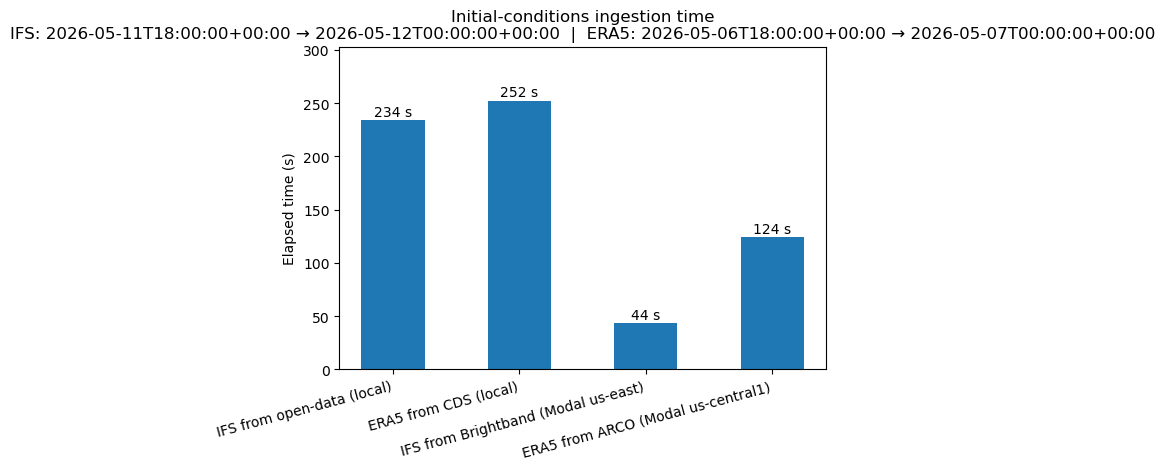

In [ ]:
fig, ax = plt.subplots()
bars = ax.bar(results.index, results["elapsed_s"], width=0.5)
for bar, val in zip(bars, results["elapsed_s"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val:.0f} s",
        ha="center",
        va="bottom",
    )
ax.set_ylabel("Elapsed time (s)")
ax.set_title(
    f"Initial-conditions ingestion time\n"
    f"IFS: {IFS_DATE_START} → {IFS_DATE_END}  |  "
    f"ERA5: {ERA5_DATE_START} → {ERA5_DATE_END}"
)
ax.set_ylim(0, max(results["elapsed_s"]) * 1.2)
fig.autofmt_xdate(rotation=15, ha="right")
fig.tight_layout()

## Summary

- **IFS from open-data (local)** — fetches ECMWF open-data GRIB from AWS via `earthkit-data`, regrids to N320. No credentials needed. ~2 years of coverage.
- **ERA5 from CDS (local)** — submits CDS API requests (surface, soil, pressure-level), waits for the CDS queue, downloads GRIB, regrids to N320. Covers the full ERA5 archive back to 1940; queue latency dominates.
- **IFS from Brightband (Modal, `us-east`)** — zarr-to-zarr read with variable name mapping and regrid from the Earthmover ArrayLake marketplace. Requires `ARRAYLAKE_API_TOKEN`.
- **ERA5 from ARCO (Modal, `us-central1`)** — one Modal container handles both dates sequentially, co-located with the public GCS bucket. Includes cold-start and volume commit overhead.

## Cleanup

Remove all benchmark data from the bucket.

In [ ]:
# IC data is written to the Modal IC Volume and auto-cleaned by run_forecast.
# No S3 objects to delete here.